# Held-out all-gene perturbation statistics and pathway analysis

**Objective.** Audit the six completed directional Geneformer goal-state result tables, separate FDR significance from positive goal movement, rank coverage-qualified genes, and review enrichment with explicit biological caveats.

**Primary ranking definition.** `Goal_end_FDR < 0.05`, `Shift_to_goal_end > 0`, and `N_Detections >= 25`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

HERE = Path.cwd()
TABLES = HERE / 'source_tables'
summary = pd.read_csv(TABLES / 'comparison_summary.csv')
top_genes = pd.read_csv(TABLES / 'top_goal_shift_genes.csv')
pathways = pd.read_csv(TABLES / 'pathway_enrichment.csv')
themes = pd.read_csv(TABLES / 'pathway_theme_summary.csv')
summary

,comparison,comparison_label,genes_tested,fdr_significant,significant_toward_goal,significant_away_from_goal,qualified_toward_goal,qualified_fraction,max_positive_shift,median_qualified_shift,median_qualified_detections
0,lusc_to_luad,LUSC → LUAD,11242,321,173,148,141,0.012542,0.326040,0.005147,119.0
1,lusc_to_normal,LUSC → NORMAL,11242,364,169,195,159,0.014143,0.016771,0.002320,258.0
2,luad_to_lusc,LUAD → LUSC,13458,691,336,355,321,0.023852,0.027721,0.001085,385.0
3,luad_to_normal,LUAD → NORMAL,13458,935,438,497,396,0.029425,0.014747,0.001699,218.5
4,normal_to_luad,NORMAL → LUAD,14923,825,415,410,343,0.022985,0.164408,0.002753,308.0
5,normal_to_lusc,NORMAL → LUSC,14923,562,249,313,244,0.016351,0.047299,0.000920,356.0


## Data-quality checks

The source audit below checks row counts and missing values in the derived tables. The build script separately verifies one gene row per input comparison.

In [2]:
quality = pd.DataFrame({
    'table': ['comparison_summary', 'top_goal_shift_genes', 'pathway_enrichment', 'pathway_theme_summary'],
    'rows': [len(summary), len(top_genes), len(pathways), len(themes)],
    'missing_cells': [summary.isna().sum().sum(), top_genes.isna().sum().sum(), pathways.isna().sum().sum(), themes.isna().sum().sum()],
})
assert len(summary) == 6
assert summary['genes_tested'].between(11_000, 15_000).all()
assert (summary['qualified_toward_goal'] <= summary['significant_toward_goal']).all()
quality

,table,rows,missing_cells
0,comparison_summary,6,0
1,top_goal_shift_genes,90,0
2,pathway_enrichment,2762,0
3,pathway_theme_summary,32,0


## Statistical results

FDR significance alone includes both positive and negative centroid shifts. The qualified set adds direction and coverage requirements so the biological ranking cannot silently mix movement toward and away from the requested goal.

In [3]:
summary_view = summary.assign(
    qualified_percent=lambda x: (100 * x.qualified_fraction).round(2),
)[['comparison_label', 'genes_tested', 'fdr_significant', 'significant_toward_goal',
   'significant_away_from_goal', 'qualified_toward_goal', 'qualified_percent',
   'max_positive_shift', 'median_qualified_shift']]
summary_view

,comparison_label,genes_tested,fdr_significant,significant_toward_goal,significant_away_from_goal,qualified_toward_goal,qualified_percent,max_positive_shift,median_qualified_shift
0,LUSC → LUAD,11242,321,173,148,141,1.25,0.326040,0.005147
1,LUSC → NORMAL,11242,364,169,195,159,1.41,0.016771,0.002320
2,LUAD → LUSC,13458,691,336,355,321,2.39,0.027721,0.001085
3,LUAD → NORMAL,13458,935,438,497,396,2.94,0.014747,0.001699
4,NORMAL → LUAD,14923,825,415,410,343,2.30,0.164408,0.002753
5,NORMAL → LUSC,14923,562,249,313,244,1.64,0.047299,0.000920


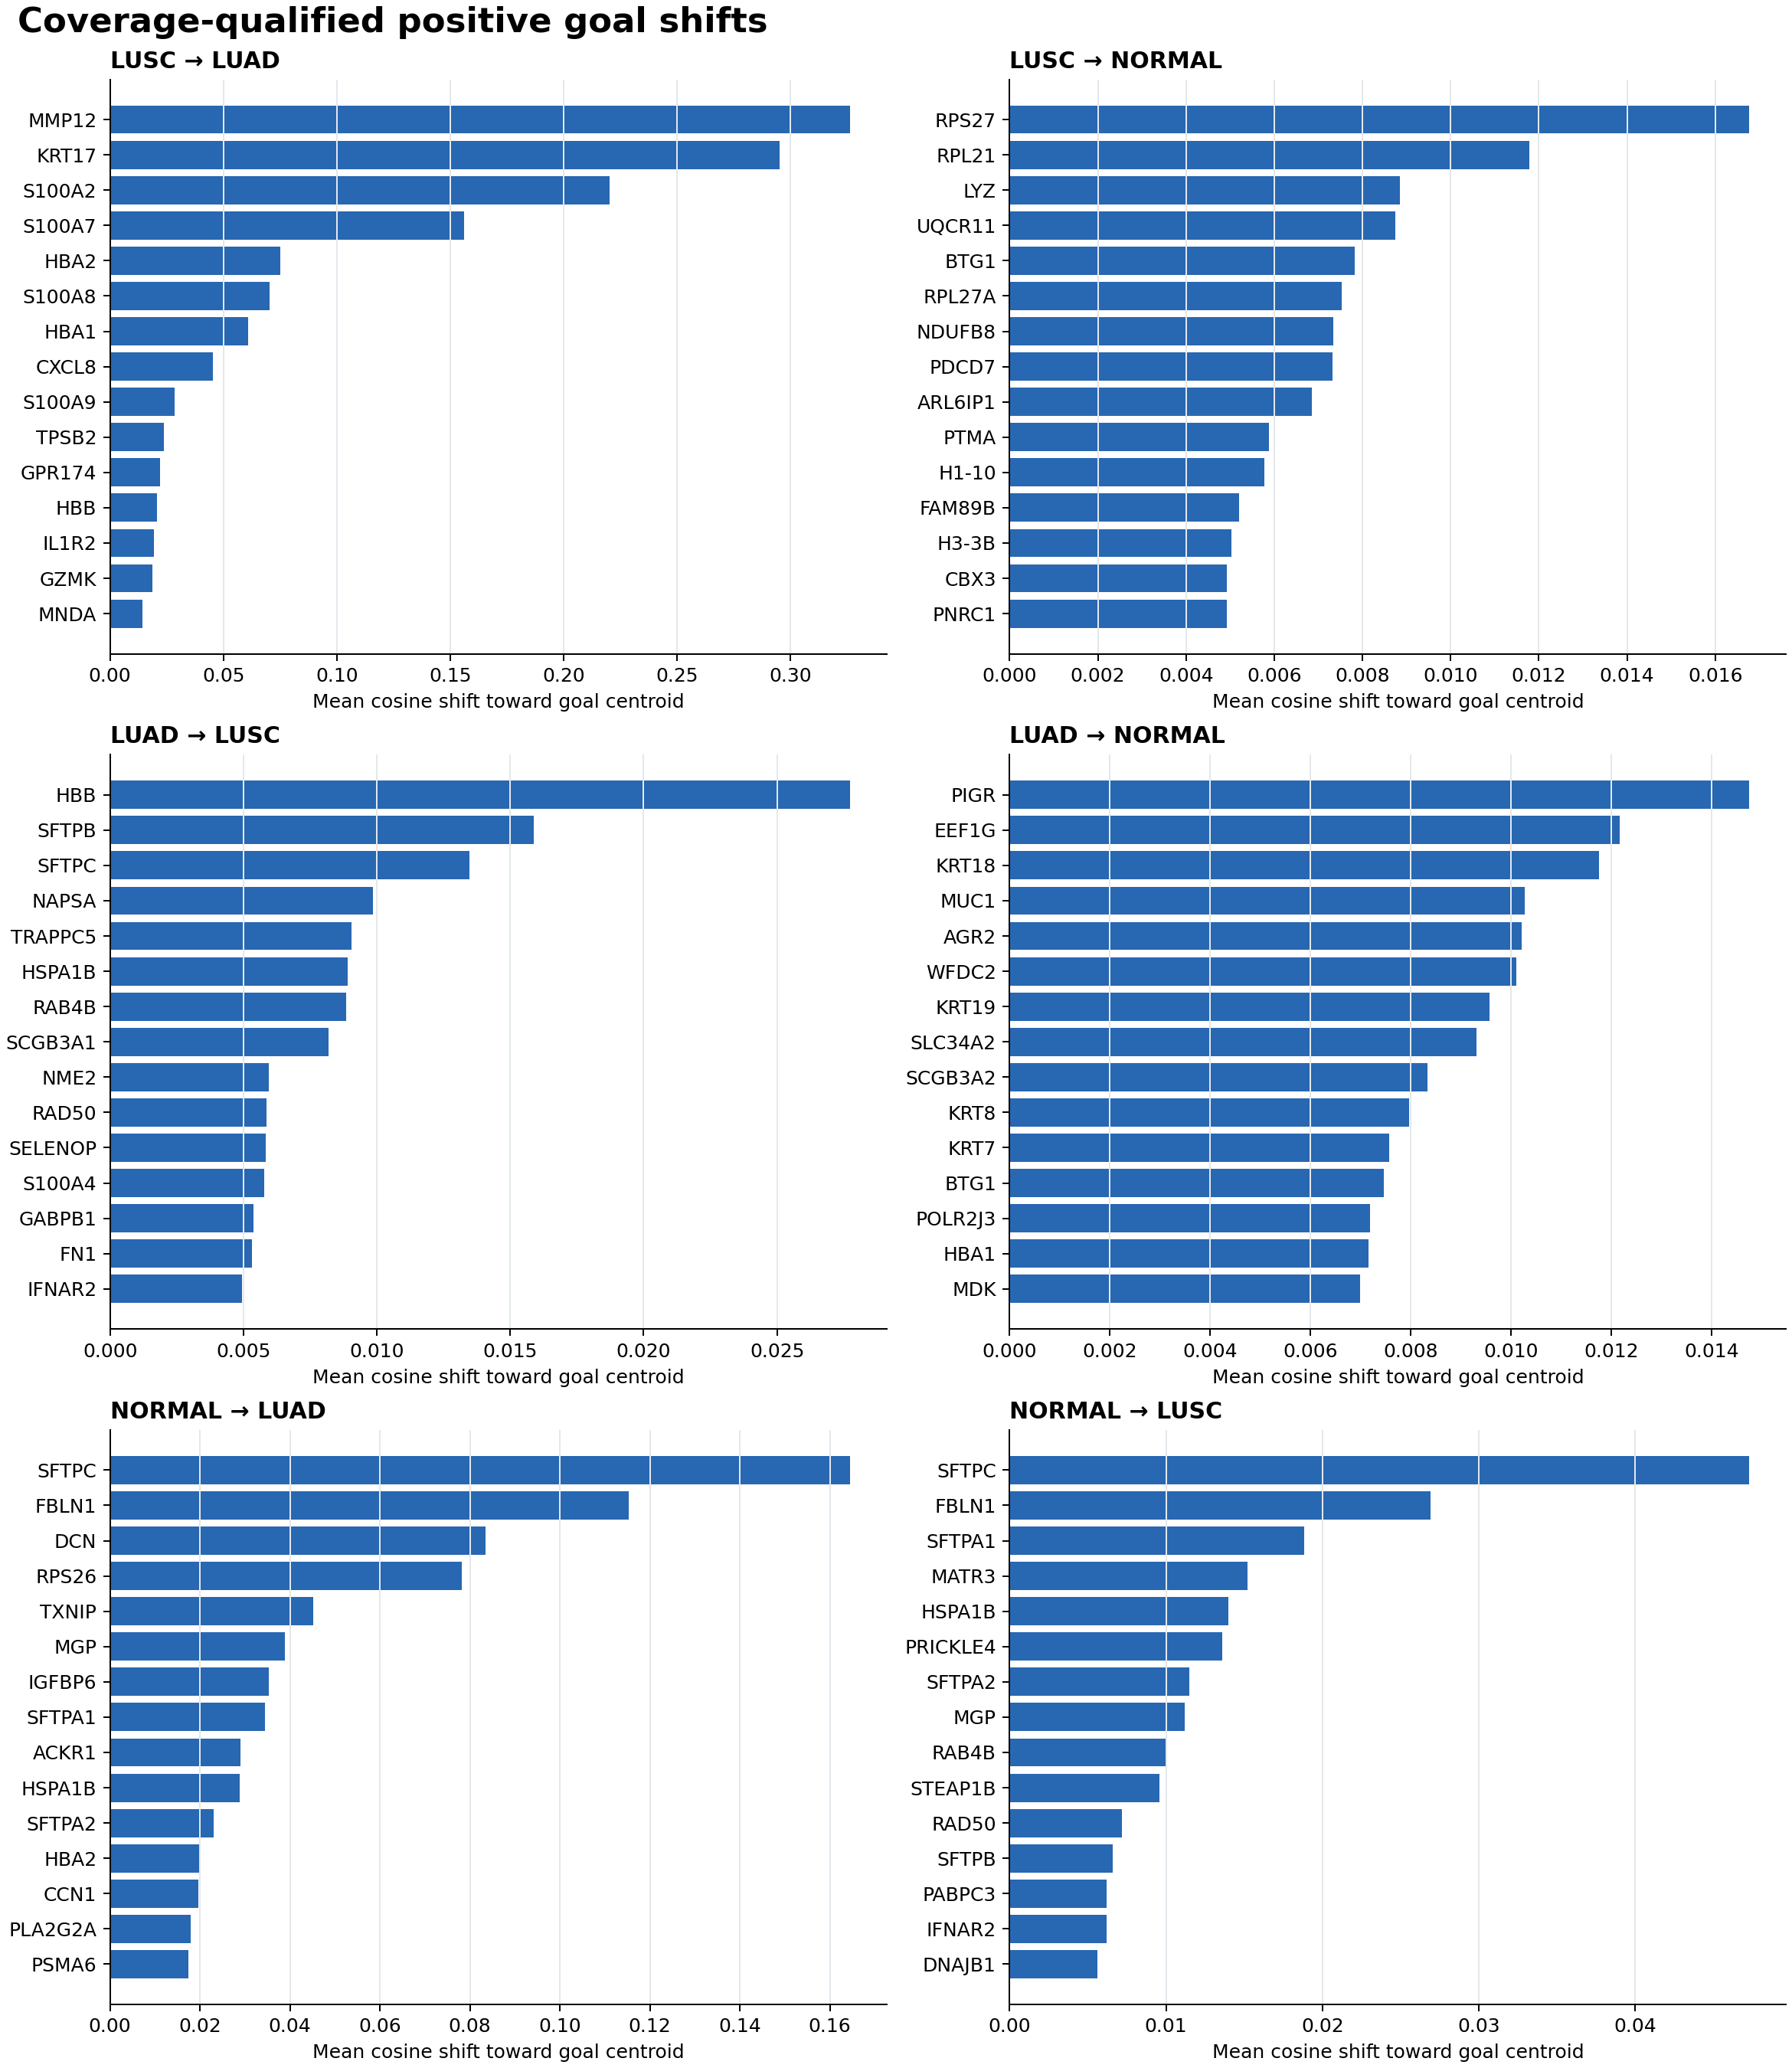

In [4]:
display(Image(filename=str(HERE / 'figures' / 'goal_shift_top_genes.png')))

## Top ranked genes by direction

The table retains effect size, FDR, detection count, rank, and stable Ensembl identifier. A positive shift means movement toward a centroid after deletion—not increased expression in the goal state and not evidence of therapeutic benefit.

In [5]:
top_genes.query('rank <= 10')[['comparison_label', 'rank', 'Gene_name', 'Shift_to_goal_end', 'Goal_end_FDR', 'N_Detections']]

,comparison_label,rank,Gene_name,Shift_to_goal_end,Goal_end_FDR,N_Detections
0,LUSC → LUAD,1,MMP12,0.326040,2.924498e-16,28
1,LUSC → LUAD,2,KRT17,0.295016,2.147192e-23,41
2,LUSC → LUAD,3,S100A2,0.220368,1.054243e-17,35
3,LUSC → LUAD,4,S100A7,0.156212,1.082884e-14,35
4,LUSC → LUAD,5,HBA2,0.074947,2.982294e-75,135
5,LUSC → LUAD,6,S100A8,0.070495,1.604805e-70,134
6,LUSC → LUAD,7,HBA1,0.060982,2.814700e-52,105
7,LUSC → LUAD,8,CXCL8,0.045412,4.735211e-06,28
8,LUSC → LUAD,9,S100A9,0.028490,1.086508e-43,134
9,LUSC → LUAD,10,TPSB2,0.023604,4.601156e-04,36


## Pathway analysis

g:Profiler enrichment used the tested genes in each comparison as the custom background. Reactome, KEGG, and GO Biological Process terms were FDR corrected by g:Profiler. The theme table consolidates redundant significant terms with predefined text patterns; it is descriptive rather than a new inferential layer.

In [6]:
themes[['comparison_label', 'theme', 'best_adjusted_p_value', 'matching_term_count',
        'representative_source', 'representative_term', 'intersection_size']]

,comparison_label,theme,best_adjusted_p_value,matching_term_count,representative_source,representative_term,intersection_size
0,LUAD → LUSC,Translation / ribosome,5.367150e-32,21,REAC,L13a-mediated translational silencing of Cerul...,38
1,LUAD → LUSC,Oxidative phosphorylation,5.726935e-14,13,KEGG,Oxidative phosphorylation,23
2,LUAD → LUSC,Immune / cytokine,1.647066e-06,53,GO:BP,immune system process,89
3,LUAD → LUSC,IL-17 / inflammation,1.169645e-04,1,REAC,Neutrophil degranulation,26
4,LUAD → LUSC,Antigen processing,2.499899e-03,7,KEGG,Antigen processing and presentation,8
5,LUAD → LUSC,Cellular stress,6.990366e-03,1,GO:BP,response to stress,101
6,LUAD → NORMAL,Translation / ribosome,5.841413e-58,32,REAC,Eukaryotic Translation Elongation,54
7,LUAD → NORMAL,Immune / cytokine,1.488382e-19,128,GO:BP,immune response,108
8,LUAD → NORMAL,Cellular stress,2.907550e-08,3,GO:BP,response to stress,142
9,LUAD → NORMAL,Antigen processing,1.877146e-06,29,KEGG,Antigen processing and presentation,13


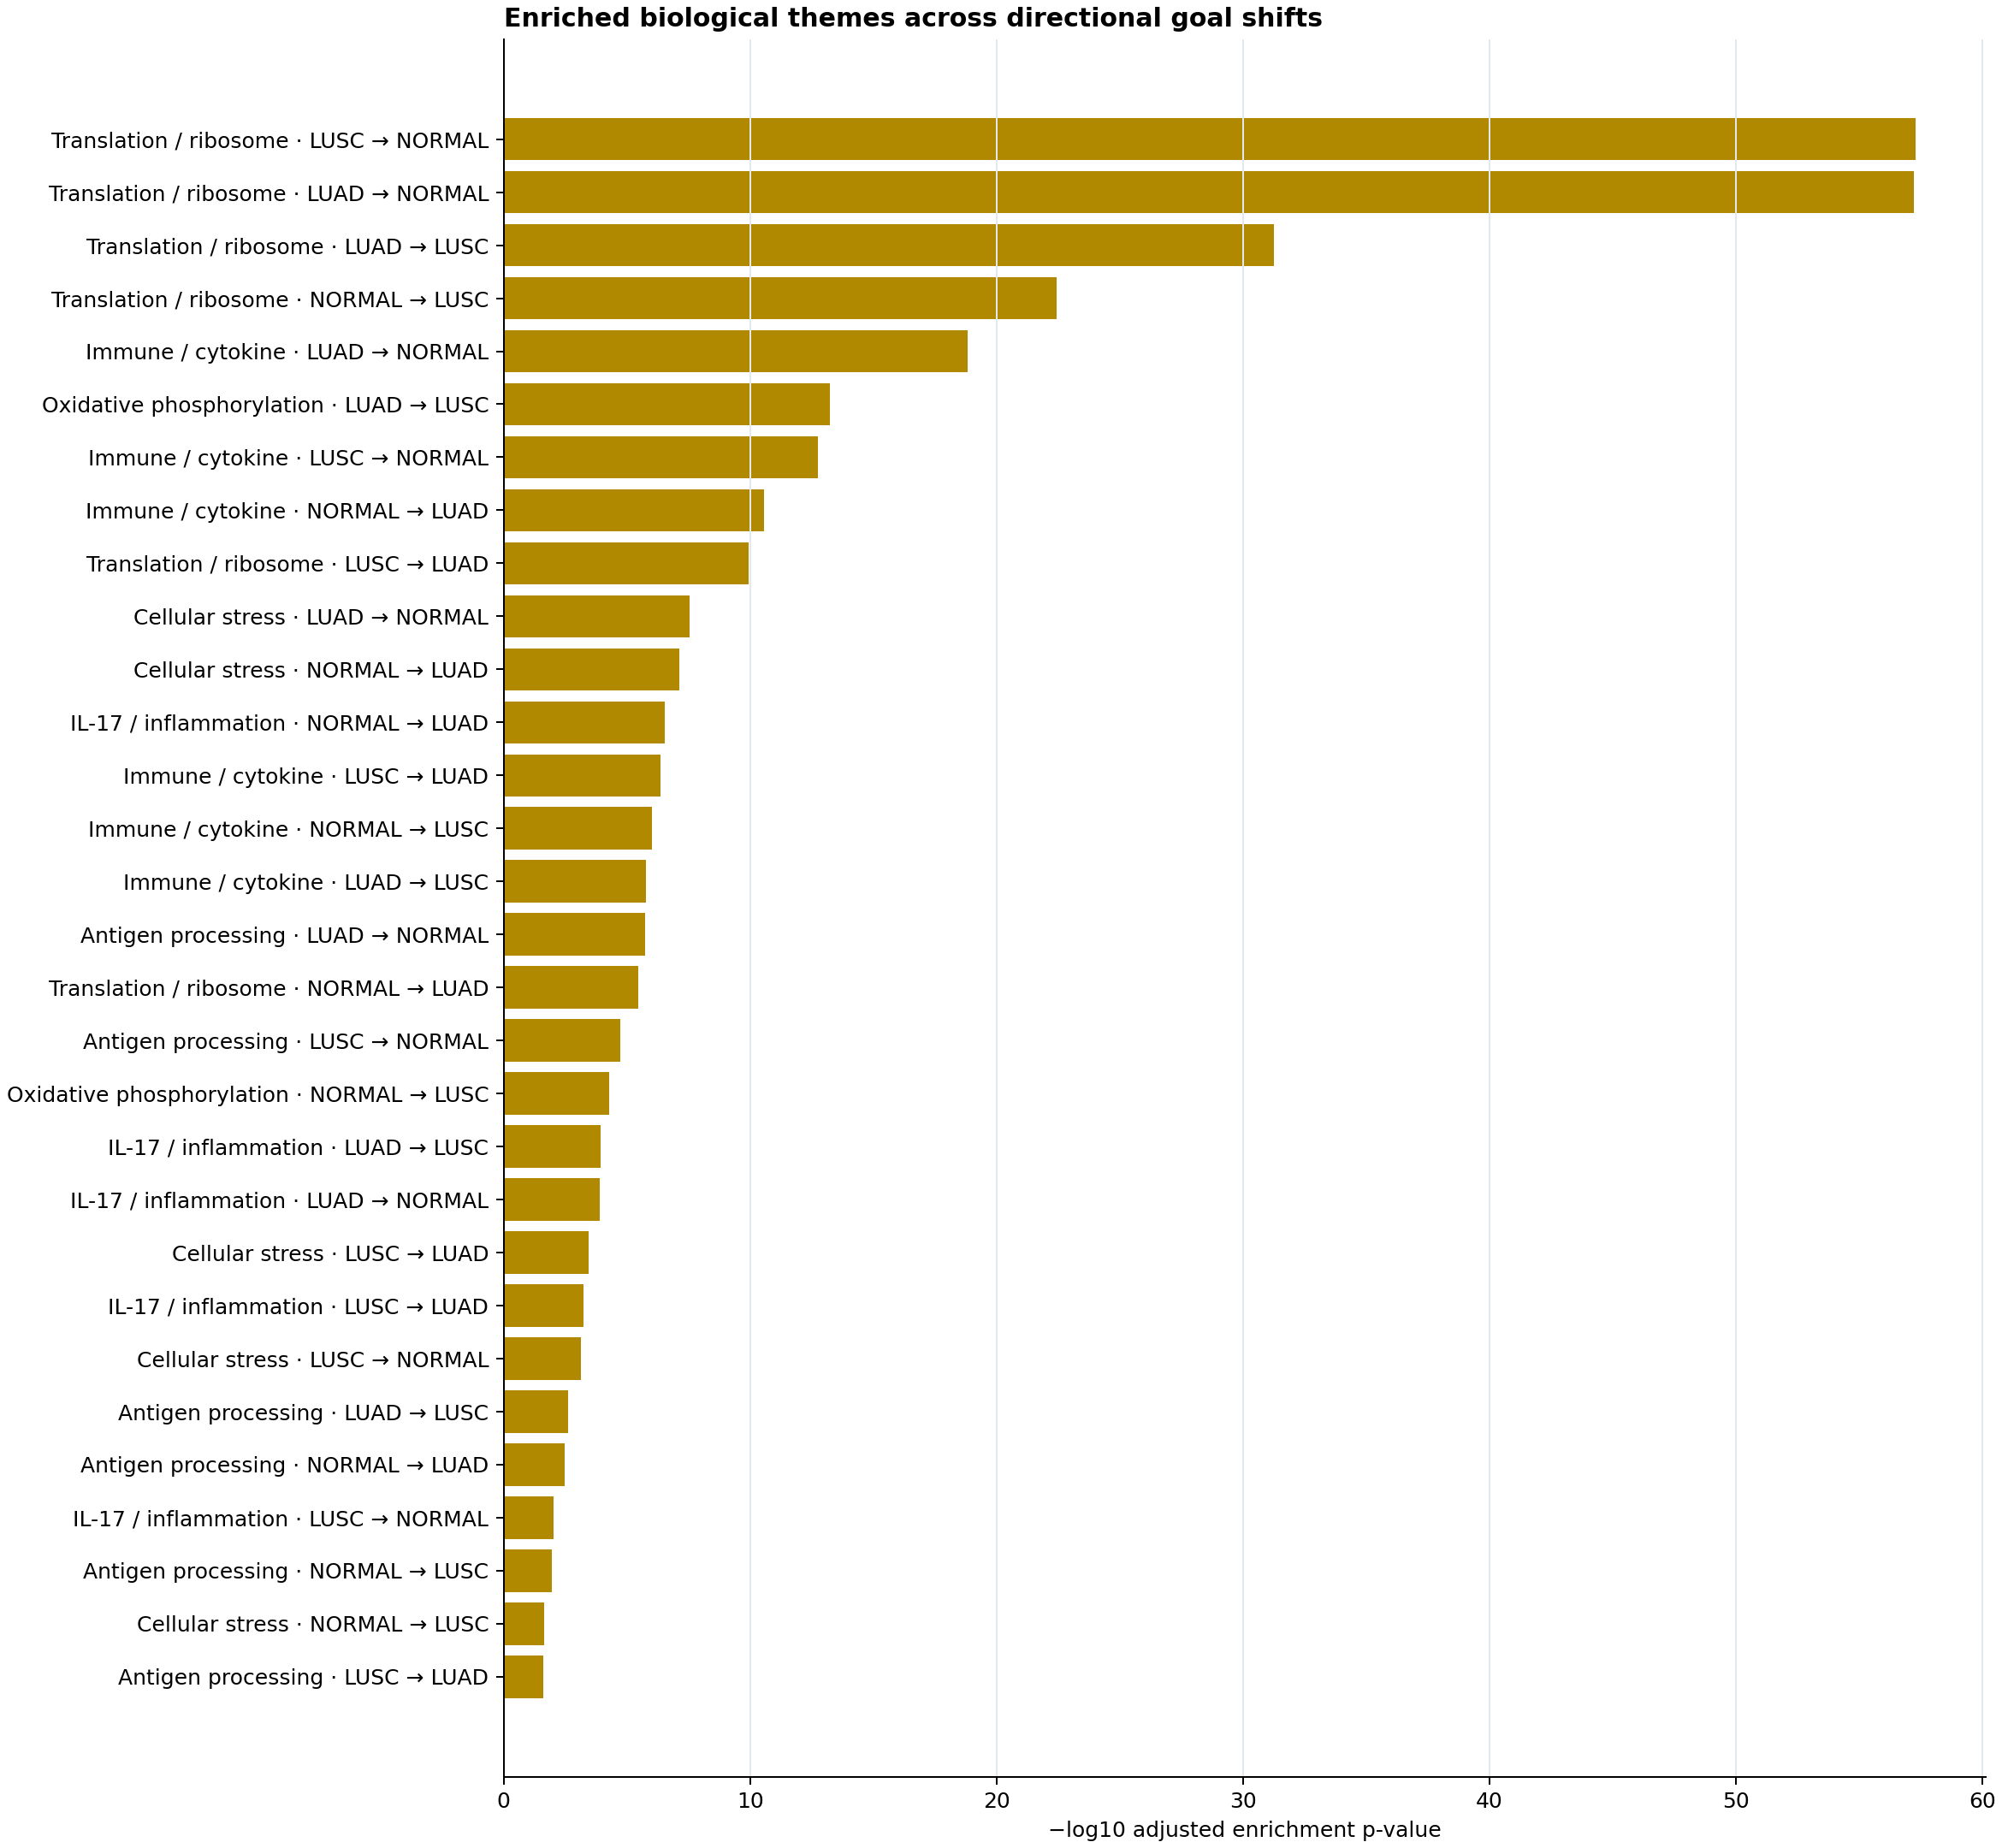

In [7]:
display(Image(filename=str(HERE / 'figures' / 'pathway_enrichment.png')))

## Biological interpretation and decision

- **Recurring programs:** translation/ribosome and immune/cytokine terms dominate; oxidative phosphorylation is strongest in LUAD → LUSC and also appears in NORMAL → LUSC.
- **Cell-identity warning:** SFTPB/SFTPC/NAPSA, MUC1/PIGR/keratins, and FBLN1/DCN/ACKR1 are difficult to reconcile as purely intrinsic T-cell programs. Ambient RNA, doublets, and tissue composition are plausible drivers.
- **Decision:** share as a prioritization screen with caveats; do not nominate causal targets until donor-stratified stability and decontamination sensitivity are demonstrated.

### Next analyses

1. Compute per-donor effects and leave-one-donor-out ranks.
2. Repeat after ambient-RNA correction and doublet/high-epithelial-burden exclusion.
3. Compare perturbation direction with source-versus-goal differential expression.
4. Validate prioritized T-cell-specific genes in an independent donor-balanced cohort.